##Inspecting the images

In [1]:
from IPython.display import Image, display


Displaying images: apple.jpg


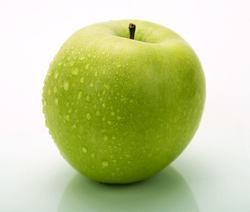


Displaying images: clock.jpg


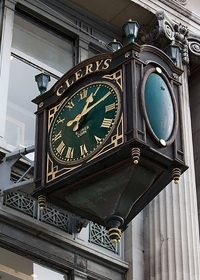


Displaying images: oranges.jpg


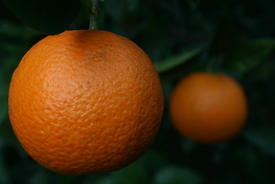


Displaying images: car.jpg


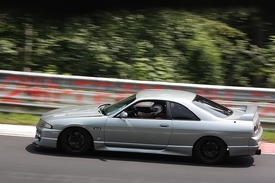

In [2]:
img_files = ['apple.jpg','clock.jpg','oranges.jpg','car.jpg']

for img in img_files:
    print(f"\nDisplaying images: {img}")
    display(Image(filename=f"images/{img}"))

##Creating the detect_and_draw_box function

In [3]:
import os

dir_name = "images_with_boxes"
if not os.path.exists(dir_name):
    os.mkdir(dir_name)

In [4]:
import sys
!{sys.executable} -m pip install --upgrade pip setuptools wheel

  Using cached setuptools-82.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
Using cached setuptools-82.0.0-py3-none-any.whl (1.0 MB)
Using cached wheel-0.46.3-py3-none-any.whl (30 kB)

   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- -------------------

In [5]:
import sys
!{sys.executable} -m pip install opencv-python-headless

  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)
Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl (12.3 MB)

   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   -----------------------

In [6]:
!{sys.executable} -m pip install opencv-python-headless cvlib tensorflow-cpu pillow

  Using cached cvlib-0.2.7-py3-none-any.whl
  Using cached tensorflow_cpu-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached progressbar-2.5-py3-none-any.whl
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached imageio-2.37.2-py3-none-any.whl.metadata (9.7 kB)
  Using cached imutils-0.5.4-py3-none-any.whl
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached

In [27]:
import cv2

import cvlib as cv
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 3 <-- Filter out INFO, WARNING, and only show ERROR message
import cvlib as cv

from cvlib.object_detection import draw_bbox 

def detect_and_draw_box(filename,model = 'yolov3-tiny',confidence = 0.5):

    img_filepath = f"images/{filename}"   # Images are stored under the images/ directory
    
    img = cv2.imread(img_filepath)  ## Read the image into a numpy array

    bbox,label,conf = cv.detect_common_objects(img,confidence = confidence, model = model)   # Perform the object detection

    print(f"=================\nImage processeed:{filename}\n")

    for l,c in zip(label,conf):
        print(f"Detected object: {l} with confidece level of {c:.2f}\n")

    output_image = draw_bbox(img,bbox,label,conf)    # Create a new image that includes the bounding boxes

    cv2.imwrite(f'images_with_boxes/{filename}',output_image)   # Save the image in the directory images_with_boxes

    display(Image(f'images_with_boxes/{filename}'))


Image processeed:apple.jpg

Detected object: apple with confidece level of 0.57



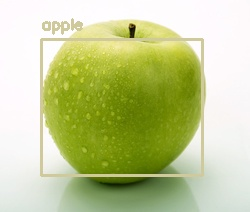

Image processeed:clock.jpg

Detected object: clock with confidece level of 0.97



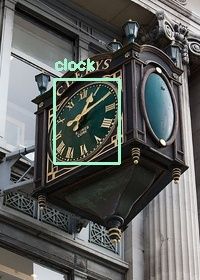

Image processeed:oranges.jpg

Detected object: orange with confidece level of 0.62

Detected object: orange with confidece level of 0.56



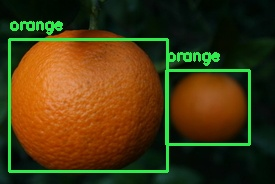

Image processeed:car.jpg

Detected object: car with confidece level of 0.63



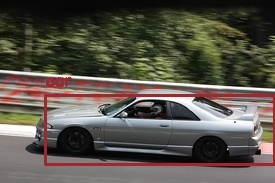

In [28]:
for image in img_files:
    detect_and_draw_box(image)

###Changing the confidence level

Image processeed:fruits.jpg

Detected object: apple with confidece level of 0.58

Detected object: orange with confidece level of 0.53

Detected object: orange with confidece level of 0.52



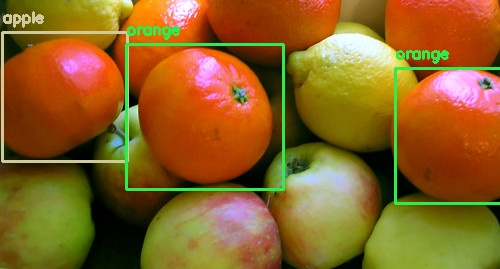

In [29]:
detect_and_draw_box("fruits.jpg")

Image processeed:fruits.jpg

Detected object: apple with confidece level of 0.58

Detected object: orange with confidece level of 0.53

Detected object: orange with confidece level of 0.52

Detected object: apple with confidece level of 0.35

Detected object: orange with confidece level of 0.33

Detected object: apple with confidece level of 0.31



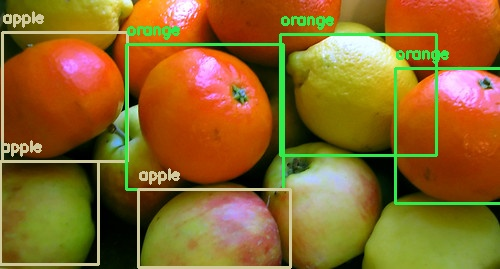

In [32]:
detect_and_draw_box("fruits.jpg",confidence=0.3)

##Deploying the model using FastAPI